# Start

In [16]:
import torch
import torch.nn.functional as F
import tqdm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from wavegen import generate_multiwave


device = 'cuda'

# Definitions

In [17]:
class LinearLSQR(torch.nn.Module):
    def __init__(self, x, y, device):
        super().__init__()
        self.slope, self.intercept = torch_least_squares_simple(x, y)
        self.slope.to(device)
        self.intercept.to(device)

    def forward(self, x):
        return self.slope * x + self.intercept


class SineNN(torch.nn.Module):
    def __init__(self, params):
        super().__init__()
        self.frequency_allowance = params['frequency_allowance']
        self.amplitude_allowance = params['amplitude_allowance']
        self.middle_density = params['middle_density'] 
        self.min_amplitude = params['min_amplitude']
        self.max_amplitude = params['max_amplitude']
        self.min_frequency = params['min_frequency']
        self.max_frequency = params['max_frequency']
        self.amplitude = torch.nn.Parameter(params['amplitude'])
        self.frequency = torch.nn.Parameter((self.min_frequency + self.max_frequency) / 2)
        self.phase = torch.nn.Parameter(params['phase'])

    def forward(self, x):
        self.frequency_bound = torch.clamp(
            self.frequency,
            self.min_frequency * (1 - self.frequency_allowance),
            self.max_frequency * (1 + self.frequency_allowance)
        )
        self.amplitude_bound = torch.clamp(
            self.amplitude,
            self.min_amplitude * (1 - self.amplitude_allowance),
            self.max_amplitude
        )
        sin_wave = self.amplitude_bound * torch.sin(self.frequency_bound * x - self.phase)
        return sin_wave


def torch_least_squares_simple(x, y) -> tuple:
    '''
    Both x and y are 1D arrays
    returns (a, b) from y = ax + b
    '''
    n = len(x)
    sum_x = torch.sum(x)
    sum_y = torch.sum(y)
    sum_xy = torch.sum(x * y)
    sum_x2 = torch.sum(x ** 2)
    denominator = n * sum_x2 - sum_x ** 2
    a = (n * sum_xy - sum_x * sum_y) / denominator
    b = (sum_y * sum_x2 - sum_x * sum_xy) / denominator
    return a, b

   
def normalize_torch(
    array: torch.Tensor,
    min_: float = None,
    max_: float = None
):
    if len(torch.unique(array)) == 1:
        value = torch.unique(array)[0]
        norm_value = 0.5
        if max_ != min_:
            norm_value = (value - min_) / (max_ - min_)
        return torch.ones_like(array) * norm_value    
    if min_ is None:
        min_ = array.min()
    if max_ is None:
        max_ = array.max()        
    return (array - min_) / (max_ - min_)


def denormalize_torch(
    normalized_array: torch.Tensor,
    min_: float,
    max_: float
) -> torch.Tensor:
    return normalized_array * (max_ - min_) + min_


def freeze_parameters(model, whitelist):
    for param in model.parameters():
        param.requires_grad = False
    for name, param in model.named_parameters():
        if name in whitelist:
            param.requires_grad = True


def get_max_gap_bool_vec(bool_vec: torch.Tensor) -> int:
    z = (~bool_vec).int()
    p = torch.cat([torch.tensor([0], device=bool_vec.device), z, torch.tensor([0], device=bool_vec.device)])
    runs = (torch.diff(p) == -1).nonzero(as_tuple=True)[0] - (torch.diff(p) == 1).nonzero(as_tuple=True)[0]
    return runs.max() if runs.numel() > 0 else 0


def get_median_gap_bool_vec(bool_vec: torch.Tensor) -> int:
    z = (~bool_vec).int()
    p = torch.cat([torch.tensor([0], device=bool_vec.device), z, torch.tensor([0], device=bool_vec.device)])
    runs = (torch.diff(p) == -1).nonzero(as_tuple=True)[0] - (torch.diff(p) == 1).nonzero(as_tuple=True)[0]
    return runs.median() if runs.numel() > 0 else 0


def rolling_mean_centered_unbiased(x, window):
    assert window % 2 == 1
    x = x.unsqueeze(0).unsqueeze(0)  # (1,1,N)
    kernel = torch.ones(1, 1, window, device=x.device, dtype=x.dtype)
    pad = window // 2
    sums = F.conv1d(x, kernel, padding=pad)
    counts = F.conv1d(torch.ones_like(x), kernel, padding=pad)
    return (sums / counts).squeeze()


def find_intersections(x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    a = x[:-1]
    b = x[1:]
    mask = ((a <= t) & (t <= b)) | ((b <= t) & (t <= a))
    return torch.nonzero(mask, as_tuple=True)[0]


def get_max_gap(intersections, len_):
    device = intersections.device      
    padded = torch.cat([torch.tensor([0], device=device), intersections, torch.tensor([len_-1], device=device)])
    return padded.diff().max()


def get_median_gap(intersections):
    return intersections.diff().median()


def get_init_sin_params(
    x, y_hornorm, rolling_window: int = None,
    frequency_allowance: float = 0.01,
    amplitude_allowance: float = 0.01
):
    if rolling_window is not None:
        assert rolling_window % 2, 'Window must be odd'
        y_hornorm_rolling = rolling_mean_centered_unbiased(y_hornorm, rolling_window)
    else:
        y_hornorm_rolling = y_hornorm    
    n = y_hornorm.numel()
    intersections = find_intersections(y_hornorm_rolling, 0)
    frequency = torch.pi / get_max_gap(intersections, n)
    phase = frequency * intersections[0]
    x_angular = frequency * x
    pred = torch.sin(x_angular - phase)
    sign = torch.sign((y_hornorm_rolling * pred).sum())
    # phase = phase + (sign < 0) * torch.pi
    min_amplitude = (y_hornorm_rolling.max() - y_hornorm_rolling.min()) / 2
    max_amplitude = (y_hornorm.max() - y_hornorm.min()) / 2
    return {
        'frequency_allowance': frequency_allowance,
        'amplitude_allowance': amplitude_allowance,
        'middle_density': torch.tensor(intersections.shape[0]) / n,
        'min_frequency': frequency,
        'max_frequency': torch.pi / get_median_gap(intersections),
        'min_amplitude': min_amplitude,
        'max_amplitude': max_amplitude,
        'amplitude': (max_amplitude + min_amplitude) / 2,           
        'phase': phase
    }


def compute_density_loss(sin_wave, sinwave_params):
    '''
    It is assumed that the wave is horizontal -0.5 to 0.5 normalized
    '''
    middle_density_target = sinwave_params['middle_density']
    n = sin_wave.numel()
    intersections = find_intersections(sin_wave, 0)
    middle_density_hat = torch.tensor(intersections.shape[0]) / n
    density_loss = (middle_density_hat - middle_density_target) ** 2
    return density_loss


def train_sinenn(
    sinenn, x, y, sinwave_params: dict,
    steps_phase: int = 50,
    steps_freq: int = 100,
    steps_amplitude: int = 25,
    iterations: int = 5,
    learning_rate: float = 0.01    
):
    history = []
    # y_hat = sinenn(x)
    # density_loss = compute_density_loss(y_hat, sinwave_params)
    for iteration in tqdm.tqdm(range(iterations)):
        optimizer = torch.optim.Adam(sinenn.parameters(), lr=learning_rate)
        freeze_parameters(sinenn, whitelist=['phase'])
        for step in range(steps_phase):
            optimizer.zero_grad()
            y_hat = sinenn(x)
            loss = torch.mean((y_hat - y) ** 2) #+ density_loss
            loss.backward()
            optimizer.step()
            history.append(loss)

        freeze_parameters(sinenn, whitelist=['frequency'])
        optimizer = torch.optim.Adam(sinenn.parameters(), lr=learning_rate/100)
        for step in range(steps_freq):
            optimizer.zero_grad()
            y_hat = sinenn(x)
            density_loss = compute_density_loss(y_hat, sinwave_params)
            loss = torch.mean((y_hat - y) ** 2) + density_loss
            loss.backward()
            optimizer.step()
            history.append(loss)

    freeze_parameters(sinenn, whitelist=['amplitude'])
    optimizer = torch.optim.Adam(sinenn.parameters(), lr=learning_rate/10)
    for step in range(steps_amplitude):
        optimizer.zero_grad()
        y_hat = sinenn(x)
        loss = torch.mean((y_hat - y) ** 2) #+ density_loss
        loss.backward()
        optimizer.step()
        history.append(loss)
    return history


def waves_residual_split(x_tensor, y_tensor, num_waves, rolling_window, learning_rate, device, plot=False):
    linlsqr = LinearLSQR(x_tensor, y_tensor, device)
    slope, intercept = linlsqr.slope, linlsqr.intercept
    line = linlsqr(x_tensor)
    y_horizontal = y_tensor - line
    params = {
        'intercept': intercept,
        'slope': slope,
        'waves': []
    }
    y_hornorm = y_horizontal
    for wave_number in range(num_waves):
        min_, max_ = y_hornorm.min(), y_hornorm.max()
        y_hornorm = normalize_torch(y_hornorm, min_, max_) - 0.5
        sinwave_params = get_init_sin_params(x_tensor, y_hornorm, rolling_window=rolling_window)
        sinenn = SineNN(sinwave_params).to(device)
        if plot:
            sin_wave_untrained = sinenn(x_tensor)
            loss_untrained = (y_hornorm - sin_wave_untrained).abs().mean().item()
        history = train_sinenn(sinenn, x_tensor, y_hornorm, sinwave_params, learning_rate=learning_rate)
        with torch.no_grad():
            sin_wave = sinenn(x_tensor)
        loss_trained = (y_hornorm - sin_wave).abs().mean().item()  
        y_hornorm -= sin_wave
        params['waves'].append(
            {
                'min': min_,
                'max': max_,
                'amplitude_bound': sinenn.amplitude_bound,
                'frequency_bound': sinenn.frequency_bound,
                'phase': sinenn.phase
            }
        )
        if plot:
            plt.figure(figsize=(30, 1))
            plt.plot(x_tensor.cpu(), y_hornorm.cpu())
            plt.plot(x_tensor.cpu(), sin_wave_untrained.detach().cpu())
            plt.plot(x_tensor.cpu(), sin_wave.detach().cpu())
            loss_diff = 100 * (loss_trained - loss_untrained) / np.abs(loss_untrained)
            plt.title(f'{loss_untrained=:.2f}, {loss_trained=:.2f}, {loss_diff:.2f}%')
            plt.show()
    residual = y_hornorm
    waves_params = params
    return waves_params, residual


def reconstruct_y(x_tensor, residual, params): 
    for wave in params['waves'][::-1]:
        min_ = wave['min']
        max_ = wave['max']
        amplitude = wave['amplitude_bound']
        freq = wave['frequency_bound']
        phase = wave['phase']
        sin_wave_hornorm = amplitude * torch.sin(freq * x_tensor - phase)
        residual_normalized = residual + sin_wave_hornorm
        residual = denormalize_torch(residual_normalized + 0.5, min_, max_)        
    slope = params['slope']
    intercept = params['intercept']
    line = slope * x_tensor + intercept
    return residual + line


# Run

## Generate Multiwave

In [18]:
x, y, x_date, waves, linear_component, exponential_component = generate_multiwave(9)
x_tensor = torch.tensor(x, device=device)
y_tensor = torch.tensor(y, device=device)

## Wave-Residual split

100%|██████████| 5/5 [00:00<00:00,  8.64it/s]


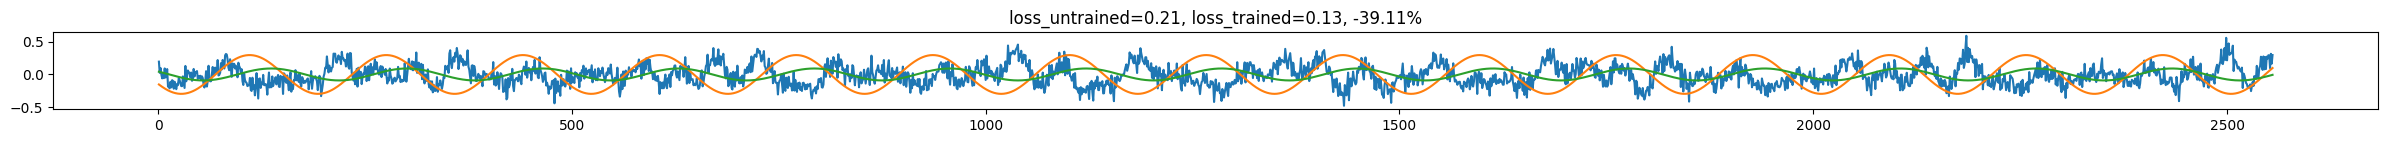

100%|██████████| 5/5 [00:00<00:00,  9.47it/s]


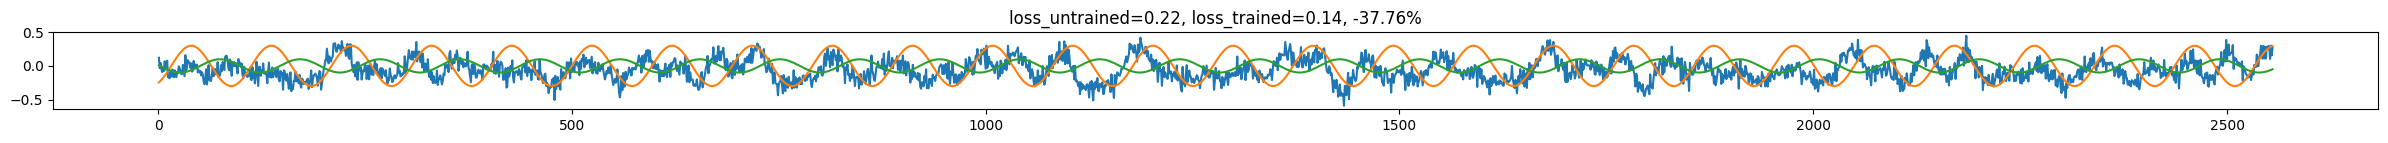

100%|██████████| 5/5 [00:00<00:00,  9.24it/s]


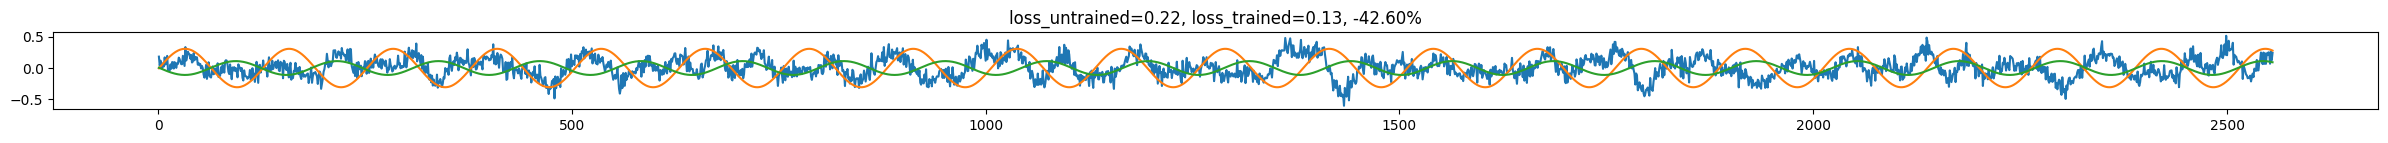

100%|██████████| 5/5 [00:00<00:00,  8.88it/s]


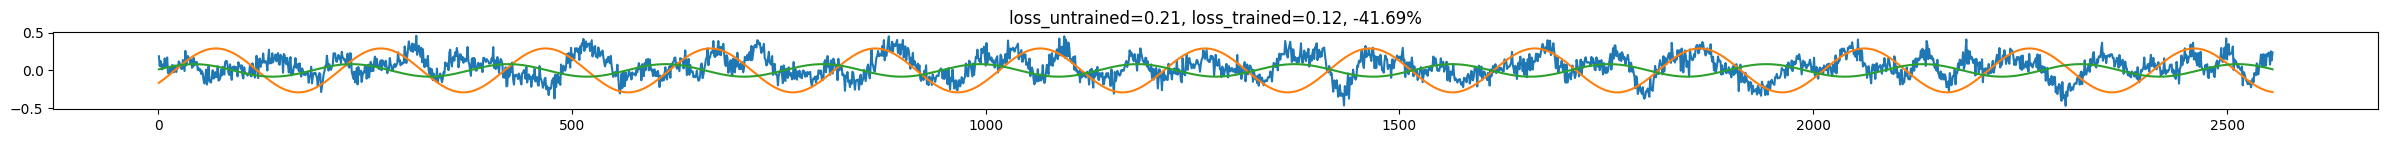

100%|██████████| 5/5 [00:00<00:00,  8.34it/s]


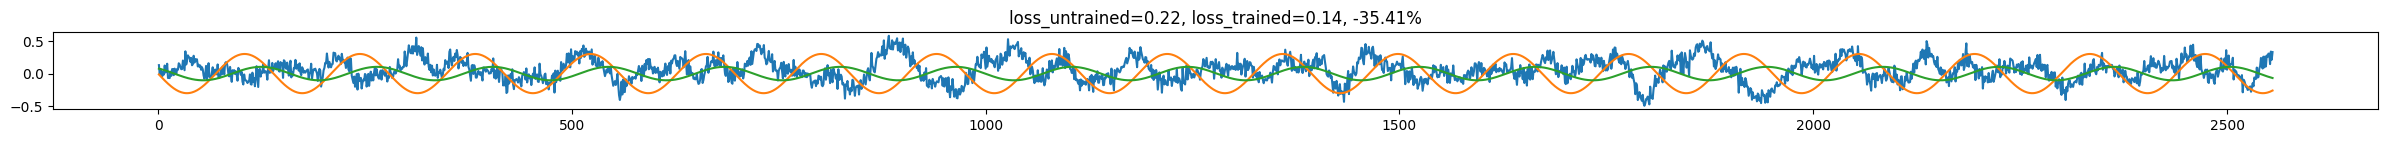

In [19]:
num_waves = 5
rolling_window = 121
learning_rate = 0.1
waves_params, residual = waves_residual_split(x_tensor, y_tensor, num_waves, rolling_window, learning_rate, device=device, plot=True)

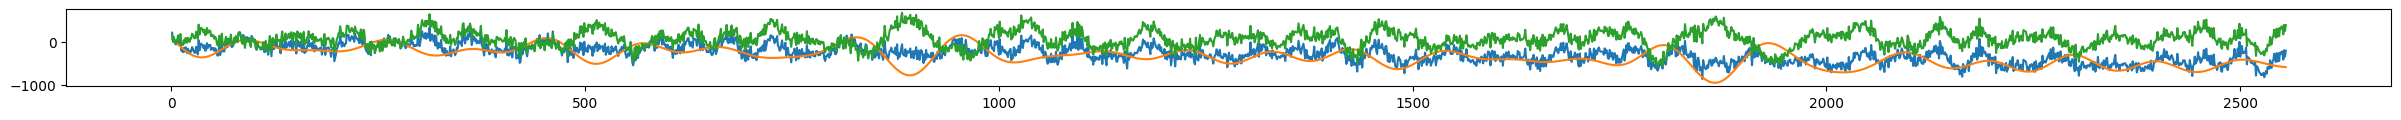

In [20]:
approximation = reconstruct_y(x_tensor, torch.zeros_like(y_tensor), waves_params)
residual = y_tensor - approximation
plt.figure(figsize=(30, 1))
plt.plot(x, y)
plt.plot(x, approximation.detach().cpu().numpy())
plt.plot(x, residual.detach().cpu().numpy())
plt.show()

# End